# Pega ADM Model Analysis

This notebook analyzes Pega Adaptive Decision Manager (ADM) model data to understand model behavior, feature importance, and build surrogate models for propensity prediction.

## Overview
- **Data Sources**: Model snapshots, predictor binning snapshots, and L5B15 decision-level data
- **Goal**: Evaluate model suitability, analyze feature importance, and build predictive surrogates

## 1. Setup & Data Loading

Three JSON Lines data files are loaded into Polars DataFrames using a streaming parser:

- **Model Snapshots** (`data-model-snapshop.json`) — one record per model version; contains snapshot-level performance metrics
- **Predictor Binning Snapshots** (`data-Predictor-binning-snapshot.json`) — one record per predictor bin; contains feature importance scores and bin statistics
- **L5B15 Decision Data** (`data.json`) — individual scoring events for the L5B15 luggage offer, including model execution results and customer input features

In [1]:
import json
import math
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from catboost import CatBoostRegressor
from IPython.display import HTML, display
from plotly.subplots import make_subplots
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from tabulate import tabulate
from tqdm import tqdm

print("Imports OK")

Imports OK


In [19]:
# Configuration
DATA_DIR = Path("../data")
MODEL_FILE = DATA_DIR / "data-model-snapshop.json"
PREDICTOR_FILE = DATA_DIR / "data-Predictor-binning-snapshot.json"
L5B15_FILE = DATA_DIR / "data.json"

#Data loader
def load_jsonl(filepath: Path, description: str = "Loading") -> list[dict]:
    """Load a JSON Lines file into a list of dictionaries.
    
    Args:
        filepath: Path to the .jsonl file
        description: Description for progress bar
    
    Returns:
        List of JSON objects
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        total_lines = sum(1 for _ in f)
    
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=total_lines, desc=description):
            records.append(json.loads(line))
    
    return records

# Load Model Snapshots
print("Loading model snapshots...")
model_records = load_jsonl(MODEL_FILE, "Model snapshots")
df_model_snapshots = pl.DataFrame(model_records)
print(f"  → {len(df_model_snapshots)} records, {len(df_model_snapshots.columns)} columns")

# Load Predictor Binning Snapshots
print("Loading predictor binning snapshots...")
predictor_records = load_jsonl(PREDICTOR_FILE, "Predictor binning")
df_predictor_binning = pl.DataFrame(predictor_records)
print(f"  → {len(df_predictor_binning)} records, {len(df_predictor_binning.columns)} columns")

# Load L5B15 offer snapshots
print("Loading L5B15 offer snapshots...")
L5B15_records = load_jsonl(L5B15_FILE, "L5B15 offer snapshots")
df_l5b15 = pl.DataFrame(L5B15_records)
print(f"  → {len(df_l5b15)} records, {len(df_l5b15.columns)} columns")


print("\n✓ Data loaded successfully")

Loading model snapshots...


Model snapshots: 100%|██████████| 161704/161704 [00:01<00:00, 129569.48it/s]


  → 161704 records, 27 columns
Loading predictor binning snapshots...


Predictor binning: 100%|██████████| 222348/222348 [00:02<00:00, 81169.06it/s]


  → 222348 records, 34 columns
Loading L5B15 offer snapshots...


L5B15 offer snapshots: 100%|██████████| 16216/16216 [00:09<00:00, 1710.62it/s]


  → 16216 records, 9 columns

✓ Data loaded successfully


## 2. Dataset Inspection

Inspect the structure, schema, and cross-dataset relationships of the three loaded datasets before proceeding to analysis.

In [ ]:
# One record per model (or model version)
print("=" * 60)
print("MODEL SNAPSHOTS")
print("=" * 60)

print(f"\nShape: {df_model_snapshots.shape}")
print(f"\nColumns:\n{df_model_snapshots.columns}")

print("\n--- Sample record ---")
df_model_snapshots.head(1).to_dicts()[0]

MODEL SNAPSHOTS

Shape: (161704, 27)

Columns:
['pyAppliesToClass', 'pyModelID', 'pyTotalPredictors', 'pxApplication', 'pyPerformance', 'pyPerformanceError', 'pyResponseCount', 'pyConfigurationName', 'pyFactoryUpdateTime', 'pyChannel', 'pyName', 'pyTreatment', 'pyDirection', 'pySnapshotTime', 'pxInsName', 'pyModelTechnique', 'pxSaveDateTime', 'pySuccessRate', 'pyGroup', 'pyNegatives', 'pyActivePredictors', 'pyPositives', 'pzInsKey', 'pyModelVersion', 'pxCommitDateTime', 'pyModelData', 'pyIssue']

--- Sample record ---


{'pyAppliesToClass': 'Data-Decision-Request-Customer',
 'pyModelID': '00116756-b49c-5a7a-a8cf-b503599fd40c',
 'pyTotalPredictors': 60,
 'pxApplication': 'PegaRULES',
 'pyPerformance': '0.500000',
 'pyPerformanceError': 0.0,
 'pyResponseCount': 113827.0,
 'pyConfigurationName': 'OmniAdaptiveModel',
 'pyFactoryUpdateTime': '20250909T100852.001 GMT',
 'pyChannel': 'Mobile',
 'pyName': 'DIVE',
 'pyTreatment': '',
 'pyDirection': 'Inbound',
 'pySnapshotTime': '20251017T050000.600 GMT',
 'pxInsName': '00116756-B49C-5A7A-A8CF-B503599FD40C!20251017T050000.600 GMT!PEGARULES',
 'pyModelTechnique': 'NaiveBayes',
 'pxSaveDateTime': '20251017T050056.206 GMT',
 'pySuccessRate': 0.0,
 'pyGroup': 'FlightAncillaries',
 'pyNegatives': 113827.0,
 'pyActivePredictors': 0,
 'pyPositives': 0.0,
 'pzInsKey': 'DATA-DECISION-ADM-MODELSNAPSHOT 00116756-B49C-5A7A-A8CF-B503599FD40C!20251017T050000.600 GMT!PEGARULES',
 'pyModelVersion': '635fbb86-0c06-5440-96b3-292c9abe6d98',
 'pxCommitDateTime': '20251017T050056.

In [4]:
# --- Predictor Binning Snapshots ---
# Multiple records per predictor (one per bin)
print("=" * 60)
print("PREDICTOR BINNING SNAPSHOTS")
print("=" * 60)

print(f"\nShape: {df_predictor_binning.shape}")
print(f"\nColumns:\n{df_predictor_binning.columns}")

# Unique predictors
unique_predictors = df_predictor_binning["pyPredictorName"].unique()
print(f"\n--- Predictor Summary ---")
print(f"Unique predictors: {len(unique_predictors)}")
print(f"Sample predictors: {unique_predictors[:5]}")

# Bins per predictor
bins_per_predictor = (
    df_predictor_binning
    .group_by("pyPredictorName")
    .agg(pl.len().alias("num_bins"))
    .sort("num_bins", descending=True)
)
print(f"\n--- Bins per Predictor (top 10) ---")
bins_per_predictor.head(10)

PREDICTOR BINNING SNAPSHOTS

Shape: (222348, 34)

Columns:
['pyBinResponseCountPercentage', 'pyContents', 'pyZRatio', 'pyModelID', 'pyBinType', 'pyBinSymbol', 'pyPredictorName', 'pyBinPositivesPercentage', 'pyBinNegativesPercentage', 'pyBinNegatives', 'pyType', 'pyBinLowerBound', 'pyPerformance', 'pyPerformanceError', 'pyResponseCount', 'pxCreateDateTime', 'pyBinIndex', 'pyLift', 'pyBinUpperBound', 'pyFeatureImportance', 'pySnapshotTime', 'pxInsName', 'pyTotalBins', 'pxSaveDateTime', 'pyNegatives', 'pyPositives', 'pyGroupIndex', 'pyEntryType', 'pzInsKey', 'pyBinPositives', 'pyBinResponseCount', 'pxCommitDateTime', 'pyRuleSetName', 'pxUpdateDateTime']

--- Predictor Summary ---
Unique predictors: 606
Sample predictors: shape: (5,)
Series: 'pyPredictorName' [str]
[
	"Event.NrOfSeats"
	"IH.Email.Inbound.Bounced.pyHis…
	"Param.DaysInbetweenBookingAndF…
	"IH.Channel.Direction.Pending.p…
	"CurrentContext.CurrentBooking.…
]

--- Bins per Predictor (top 10) ---


pyPredictorName,num_bins
str,u32
"""Classifier""",12793
"""IH.Event.Outbound.RealTimeEven…",3129
"""IH.Email.Inbound.Delivered.pxL…",2984
"""IH.Email.Inbound.Pending.pxLas…",2956
"""IH.Email.Outbound.Pending.pxLa…",2918
"""IH.Email.Outbound.Delivered.px…",2870
"""IH.Email.Outbound.Clicked.pxLa…",2851
"""IH.Email.Outbound.Pending.pyHi…",2591
"""IH.Email.Inbound.Rejected.pxLa…",2477


In [5]:
# --- Key differences between datasets ---
print("=" * 60)
print("DATASET RELATIONSHIP")
print("=" * 60)

# Model ID links both datasets
model_ids_model = df_model_snapshots["pyModelID"].unique().to_list() if "pyModelID" in df_model_snapshots.columns else []
model_ids_predictor = df_predictor_binning["pyModelID"].unique().to_list()

print(f"\nModel IDs in model snapshots: {len(model_ids_model)}")
print(f"Model IDs in predictor binning: {len(model_ids_predictor)}")

if model_ids_model:
    common = set(model_ids_model) & set(model_ids_predictor)
    print(f"Common model IDs: {len(common)}")

DATASET RELATIONSHIP

Model IDs in model snapshots: 963
Model IDs in predictor binning: 963
Common model IDs: 963


## 3. Feature Importance Analysis

Analyze the `pyFeatureImportance` field from the predictor binning snapshots to understand which predictors contribute most to model decisions. We examine the distribution of importance scores, rank predictors by aggregate importance, and compare contributions by predictor type (numeric vs. symbolic).

In [ ]:
### 3.1 Feature Importance Distribution
print("=" * 60)
print("FEATURE IMPORTANCE DISTRIBUTION")
print("=" * 60)

# Basic stats
importance_col = df_predictor_binning["pyFeatureImportance"]
print(f"\n--- Summary Statistics ---")
print(importance_col.describe())

# Distribution by importance ranges (using lit() for string literals)
print(f"\n--- Importance Range Distribution ---")
df_importance_cats = (
    df_predictor_binning
    .with_columns(
        pl.when(pl.col("pyFeatureImportance") == 0)
        .then(pl.lit("Zero"))
        .when(pl.col("pyFeatureImportance") < 0.01)
        .then(pl.lit("Low (0-0.01)"))
        .when(pl.col("pyFeatureImportance") < 0.1)
        .then(pl.lit("Medium (0.01-0.1)"))
        .otherwise(pl.lit("High (>0.1)"))
        .alias("importance_category")
    )
)
df_importance_cats.group_by("importance_category").agg(pl.len().alias("count")).sort("count", descending=True)

FEATURE IMPORTANCE DISTRIBUTION

--- Summary Statistics ---
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 222348.0 │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.267801 │
│ std        ┆ 0.303455 │
│ min        ┆ 0.0      │
│ 25%        ┆ 0.028769 │
│ 50%        ┆ 0.164032 │
│ 75%        ┆ 0.413072 │
│ max        ┆ 4.462969 │
└────────────┴──────────┘

--- Importance Range Distribution ---


importance_category,count
str,u32
"""High (>0.1)""",134986
"""Medium (0.01-0.1)""",41188
"""Low (0-0.01)""",26227
"""Zero""",19947


In [ ]:
### 3.2 Top Features by Importance
print("=" * 60)
print("TOP FEATURES BY IMPORTANCE")
print("=" * 60)

# Aggregate importance by predictor (sum across bins)
predictor_importance = (
    df_predictor_binning
    .group_by("pyPredictorName")
    .agg(
        pl.sum("pyFeatureImportance").alias("total_importance"),
        pl.len().alias("num_bins"),
        pl.first("pyType").alias("type"),
        pl.first("pyModelID").alias("model_id")
    )
    .sort("total_importance", descending=True)
)

print(f"\n--- Top 15 Predictors by Total Importance ---")
print(predictor_importance.head(15))

# Show non-zero importance predictors
print(f"\n--- Predictors with Non-Zero Importance ---")
non_zero = predictor_importance.filter(pl.col("total_importance") > 0)
print(f"Total: {len(non_zero)} predictors with importance > 0")
print(non_zero.head(10))

TOP FEATURES BY IMPORTANCE

--- Top 15 Predictors by Total Importance ---
shape: (15, 5)
┌─────────────────────────────┬──────────────────┬──────────┬─────────┬────────────────────────────┐
│ pyPredictorName             ┆ total_importance ┆ num_bins ┆ type    ┆ model_id                   │
│ ---                         ┆ ---              ┆ ---      ┆ ---     ┆ ---                        │
│ str                         ┆ f64              ┆ u32      ┆ str     ┆ str                        │
╞═════════════════════════════╪══════════════════╪══════════╪═════════╪════════════════════════════╡
│ IH.Event.Outbound.RealTimeE ┆ 1034.317377      ┆ 3129     ┆ numeric ┆ 00118d29-b883-53fc-8e58-03 │
│ ven…                        ┆                  ┆          ┆         ┆ c50b…                      │
│ IH.Mobile.Inbound.Impressio ┆ 982.655994       ┆ 2145     ┆ numeric ┆ 00118d29-b883-53fc-8e58-03 │
│ n.p…                        ┆                  ┆          ┆         ┆ c50b…                      │
│ 

In [ ]:
# 1. Distribution histogram of feature importance
fig1 = px.histogram(
    df_predictor_binning.to_pandas(),
    x="pyFeatureImportance",
    nbins=50,
    title="Distribution of Feature Importance (per bin)",
    labels={"pyFeatureImportance": "Feature Importance"},
)
fig1.show()

# 2. Top 20 predictors by total importance
top20 = predictor_importance.head(20).to_pandas()
fig2 = px.bar(
    top20,
    x="total_importance",
    y="pyPredictorName",
    orientation="h",
    title="Top 20 Predictors by Total Importance",
    labels={"total_importance": "Total Importance", "pyPredictorName": "Predictor"},
)
fig2.update_layout(yaxis=dict(autorange="reversed"))
fig2.show()

# 3. Importance split by predictor type
type_importance = (
    df_predictor_binning
    .group_by("pyType")
    .agg(pl.sum("pyFeatureImportance").alias("total_importance"))
    .to_pandas()
)
fig3 = px.pie(type_importance, values="total_importance", names="pyType", title="Importance by Predictor Type")
fig3.show()

## 4. Offer Selection and Comparison

To select models for deeper analysis, we evaluate two candidate offers from the model snapshot data. For each offer we check five viability criteria: temporal coverage (≥20 snapshots), sufficient response volume, a positive learning signal, active predictors, and acceptable model performance.

### 4.1 OnlineFlightCheckinOpen (Service – FlightInfo)

The online flight check-in offer is a high-frequency service interaction. We filter its model snapshots and evaluate each viability criterion to confirm it is a strong candidate for surrogate modelling and explanation analysis.

In [9]:
TARGET_ISSUE = "Service"
TARGET_GROUP = "FlightInfo"
TARGET_NAME = "OnlineFlightCheckinOpen"

offer_df = df_model_snapshots.filter(
    (pl.col("pyIssue") == TARGET_ISSUE) &
    (pl.col("pyGroup") == TARGET_GROUP) &
    (pl.col("pyName") == TARGET_NAME)
)

print("\n" + "=" * 60)
print(f"CHECKING OFFER: {TARGET_ISSUE} / {TARGET_GROUP} / {TARGET_NAME}")
print("=" * 60)
print(f"\nNumber of snapshot rows: {offer_df.height}")

if offer_df.height == 0:
    print("No model snapshots found for this offer.")
else:
    # Cast numeric columns safely
    offer_df = offer_df.with_columns([
        pl.col("pyResponseCount").cast(pl.Float64, strict=False),
        pl.col("pyPositives").cast(pl.Float64, strict=False),
        pl.col("pyNegatives").cast(pl.Float64, strict=False),
        pl.col("pyActivePredictors").cast(pl.Float64, strict=False),
        pl.col("pyTotalPredictors").cast(pl.Float64, strict=False),
        pl.col("pyPerformance").cast(pl.Float64, strict=False),
        pl.col("pySuccessRate").cast(pl.Float64, strict=False),
    ])

    print("\n--- Basic overview ---")
    print(
        offer_df.select([
            pl.col("pyModelID").n_unique().alias("n_model_ids"),
            pl.col("pySnapshotTime").n_unique().alias("n_snapshots"),
            pl.col("pyResponseCount").max().alias("max_response_count"),
            pl.col("pyResponseCount").mean().alias("avg_response_count"),
            pl.col("pyPositives").max().alias("max_positives"),
            pl.col("pyPositives").sum().alias("sum_positives"),
            pl.col("pyActivePredictors").max().alias("max_active_predictors"),
            pl.col("pyTotalPredictors").max().alias("max_total_predictors"),
            pl.col("pyPerformance").max().alias("max_performance"),
            pl.col("pyPerformance").mean().alias("avg_performance"),
        ])
    )

    print("\n--- Snapshot progression (latest 10) ---")
    cols_to_show = [
        c for c in [
            "pySnapshotTime",
            "pyModelID",
            "pyResponseCount",
            "pyPositives",
            "pyNegatives",
            "pyActivePredictors",
            "pyTotalPredictors",
            "pyPerformance",
            "pySuccessRate",
        ] if c in offer_df.columns
    ]

    print(
        offer_df
        .sort("pySnapshotTime")
        .select(cols_to_show)
        .tail(10)
    )

    max_resp = offer_df["pyResponseCount"].max()
    max_pos = offer_df["pyPositives"].max()
    max_active = offer_df["pyActivePredictors"].max()
    n_snapshots = offer_df["pySnapshotTime"].n_unique()

    print("\n--- Decision checks ---")
    print(f"Enough snapshots (>20)? {'YES' if n_snapshots > 20 else 'NO'}  [{n_snapshots}]")
    print(f"Has learning signal (positives > 0)? {'YES' if (max_pos or 0) > 0 else 'NO'}  [{max_pos}]")
    print(f"Has active predictors (>0)? {'YES' if (max_active or 0) > 0 else 'NO'}  [{max_active}]")
    print(f"Reasonable response volume (>200)? {'YES' if (max_resp or 0) > 200 else 'NO'}  [{max_resp}]")


CHECKING OFFER: Service / FlightInfo / OnlineFlightCheckinOpen

Number of snapshot rows: 516

--- Basic overview ---
shape: (1, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ n_model_i ┆ n_snapsho ┆ max_respo ┆ avg_respo ┆ … ┆ max_activ ┆ max_total ┆ max_perfo ┆ avg_perf │
│ ds        ┆ ts        ┆ nse_count ┆ nse_count ┆   ┆ e_predict ┆ _predicto ┆ rmance    ┆ ormance  │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ors       ┆ rs        ┆ ---       ┆ ---      │
│ u32       ┆ u32       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 4         ┆ 184       ┆ 1.0678756 ┆ 6.7741e6  ┆ … ┆ 24.0      ┆ 243.0     ┆ 0.99884   ┆ 0.697939 │
│           ┆           ┆ e7        ┆           ┆   ┆      

### 4.2 L5B15 Model (Sales – Luggage)

For comparison, we also evaluate the L5B15 luggage upsell offer — a purchase-driven model expected to show a lower positive rate and higher predictor complexity than the service-oriented check-in model.

In [10]:
TARGET_ISSUE = "Sales"
TARGET_GROUP = "Luggage"
TARGET_NAME = "L5B15"

offer_df = df_model_snapshots.filter(
    (pl.col("pyIssue") == TARGET_ISSUE) &
    (pl.col("pyGroup") == TARGET_GROUP) &
    (pl.col("pyName") == TARGET_NAME)
)

print("\n" + "=" * 60)
print(f"CHECKING OFFER: {TARGET_ISSUE} / {TARGET_GROUP} / {TARGET_NAME}")
print("=" * 60)
print(f"\nNumber of snapshot rows: {offer_df.height}")

if offer_df.height == 0:
    print("No model snapshots found for this offer.")
else:
    # Cast numeric columns safely
    offer_df = offer_df.with_columns([
        pl.col("pyResponseCount").cast(pl.Float64, strict=False),
        pl.col("pyPositives").cast(pl.Float64, strict=False),
        pl.col("pyNegatives").cast(pl.Float64, strict=False),
        pl.col("pyActivePredictors").cast(pl.Float64, strict=False),
        pl.col("pyTotalPredictors").cast(pl.Float64, strict=False),
        pl.col("pyPerformance").cast(pl.Float64, strict=False),
        pl.col("pySuccessRate").cast(pl.Float64, strict=False),
    ])

    print("\n--- Basic overview ---")
    print(
        offer_df.select([
            pl.col("pyModelID").n_unique().alias("n_model_ids"),
            pl.col("pySnapshotTime").n_unique().alias("n_snapshots"),
            pl.col("pyResponseCount").max().alias("max_response_count"),
            pl.col("pyResponseCount").mean().alias("avg_response_count"),
            pl.col("pyPositives").max().alias("max_positives"),
            pl.col("pyPositives").sum().alias("sum_positives"),
            pl.col("pyActivePredictors").max().alias("max_active_predictors"),
            pl.col("pyTotalPredictors").max().alias("max_total_predictors"),
            pl.col("pyPerformance").max().alias("max_performance"),
            pl.col("pyPerformance").mean().alias("avg_performance"),
        ])
    )

    print("\n--- Snapshot progression (latest 10) ---")
    cols_to_show = [
        c for c in [
            "pySnapshotTime",
            "pyModelID",
            "pyResponseCount",
            "pyPositives",
            "pyNegatives",
            "pyActivePredictors",
            "pyTotalPredictors",
            "pyPerformance",
            "pySuccessRate",
        ] if c in offer_df.columns
    ]

    print(
        offer_df
        .sort("pySnapshotTime")
        .select(cols_to_show)
        .tail(10)
    )

    max_resp = offer_df["pyResponseCount"].max()
    max_pos = offer_df["pyPositives"].max()
    max_active = offer_df["pyActivePredictors"].max()
    n_snapshots = offer_df["pySnapshotTime"].n_unique()

    print("\n--- Decision checks ---")
    print(f"Enough snapshots (>20)? {'YES' if n_snapshots > 20 else 'NO'}  [{n_snapshots}]")
    print(f"Has learning signal (positives > 0)? {'YES' if (max_pos or 0) > 0 else 'NO'}  [{max_pos}]")
    print(f"Has active predictors (>0)? {'YES' if (max_active or 0) > 0 else 'NO'}  [{max_active}]")
    print(f"Reasonable response volume (>200)? {'YES' if (max_resp or 0) > 200 else 'NO'}  [{max_resp}]")


CHECKING OFFER: Sales / Luggage / L5B15

Number of snapshot rows: 1363

--- Basic overview ---
shape: (1, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ n_model_i ┆ n_snapsho ┆ max_respo ┆ avg_respo ┆ … ┆ max_activ ┆ max_total ┆ max_perfo ┆ avg_perf │
│ ds        ┆ ts        ┆ nse_count ┆ nse_count ┆   ┆ e_predict ┆ _predicto ┆ rmance    ┆ ormance  │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ors       ┆ rs        ┆ ---       ┆ ---      │
│ u32       ┆ u32       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 10        ┆ 184       ┆ 9.473462e ┆ 2.9892e6  ┆ … ┆ 48.0      ┆ 222.0     ┆ 0.873605  ┆ 0.697274 │
│           ┆           ┆ 6         ┆           ┆   ┆           ┆           ┆    

The L5B15 luggage model meets all viability criteria. Compared to the check-in model it shows a much lower positive rate (expected for a purchase offer), higher predictor complexity (up to 48 active predictors vs. ~24), and comparable average AUC (~0.70). The larger number of distinct model IDs and greater variability in predictor usage suggest a more heterogeneous model — making it a complementary case for studying explanation stability.

Both models are selected for further analysis.

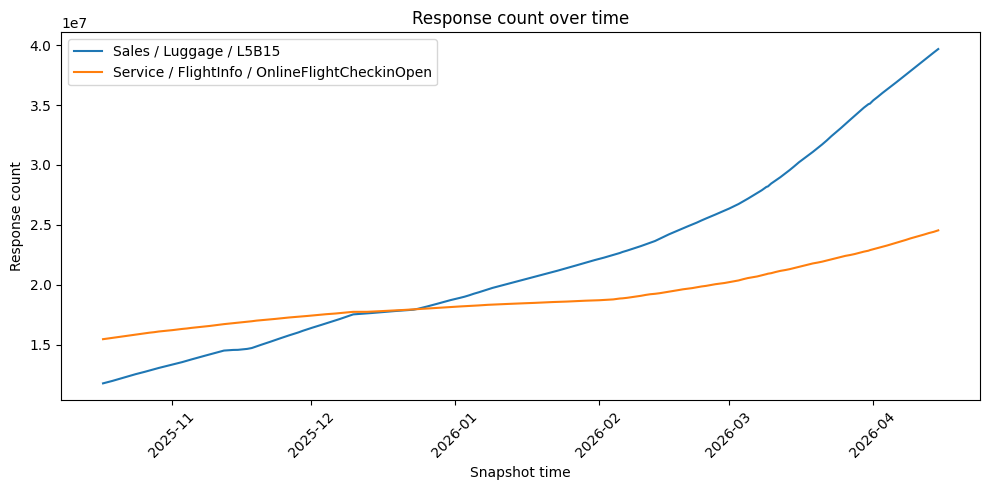

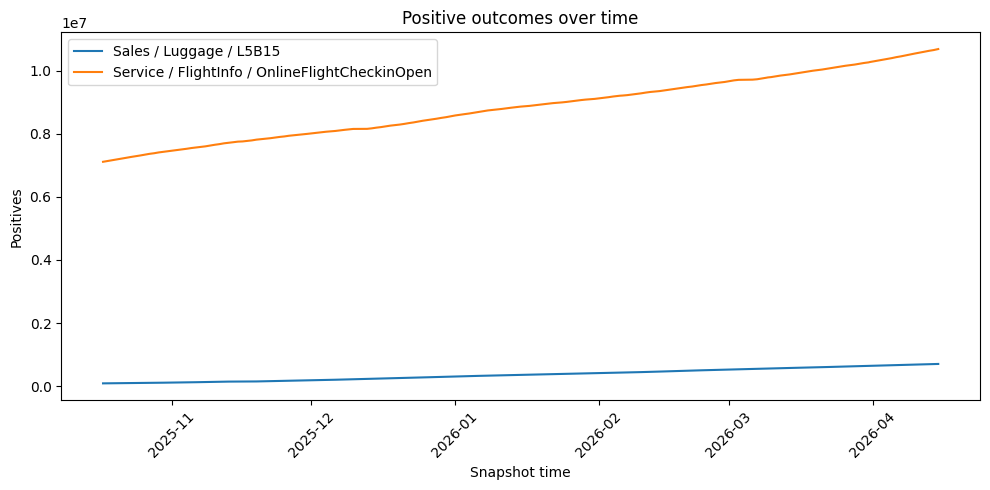

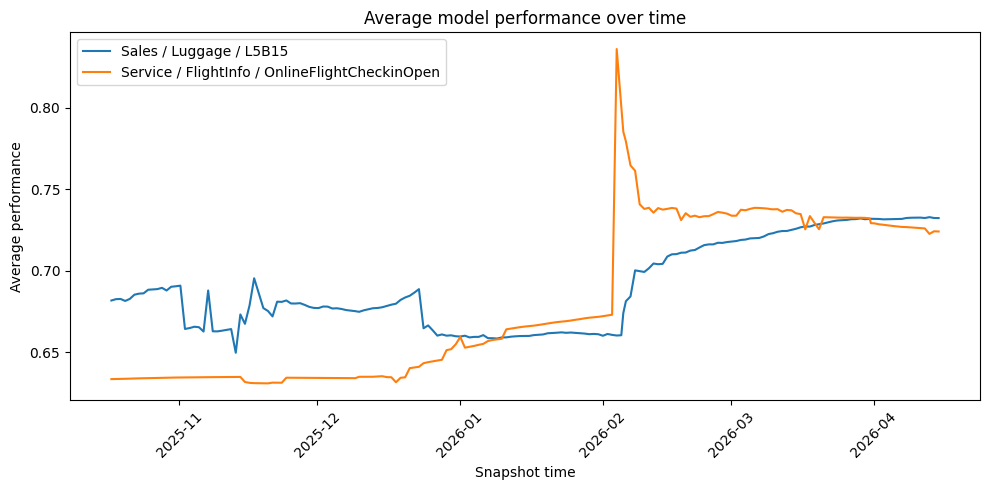

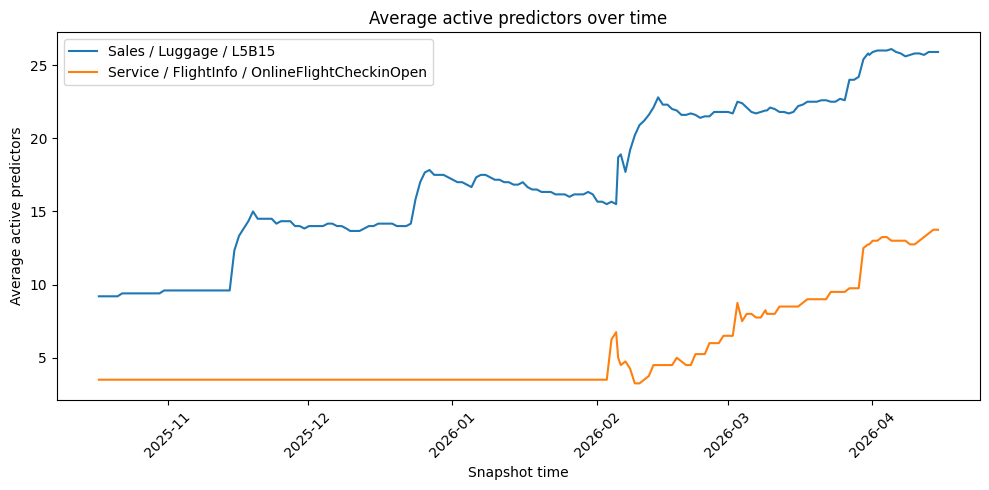

In [11]:
# --------------------------------------------------
# CONFIG: choose the two offers you want to compare
# --------------------------------------------------
OFFERS = [
    ("Service", "FlightInfo", "OnlineFlightCheckinOpen"),
    ("Sales", "Luggage", "L5B15"),
]

# --------------------------------------------------
# Helper: parse and prepare one offer
# --------------------------------------------------
def prepare_offer(df_model_snapshots, issue, group, name):
    df = df_model_snapshots.filter(
        (pl.col("pyIssue") == issue) &
        (pl.col("pyGroup") == group) &
        (pl.col("pyName") == name)
    )

    if df.height == 0:
        print(f"No rows found for {issue} / {group} / {name}")
        return None

    df = df.with_columns([
        pl.col("pyResponseCount").cast(pl.Float64, strict=False),
        pl.col("pyPositives").cast(pl.Float64, strict=False),
        pl.col("pyNegatives").cast(pl.Float64, strict=False),
        pl.col("pyActivePredictors").cast(pl.Float64, strict=False),
        pl.col("pyTotalPredictors").cast(pl.Float64, strict=False),
        pl.col("pyPerformance").cast(pl.Float64, strict=False),
        pl.col("pySuccessRate").cast(pl.Float64, strict=False),
        # Parse snapshot timestamp: keep first 15 chars like 20260415T015705
        pl.col("pySnapshotTime")
          .str.slice(0, 15)
          .str.strptime(pl.Datetime, format="%Y%m%dT%H%M%S", strict=False)
          .alias("snapshot_dt")
    ])

    # Aggregate per snapshot moment across model IDs
    out = (
        df.group_by("snapshot_dt")
        .agg([
            pl.col("pyResponseCount").sum().alias("response_count"),
            pl.col("pyPositives").sum().alias("positives"),
            pl.col("pyNegatives").sum().alias("negatives"),
            pl.col("pyActivePredictors").mean().alias("avg_active_predictors"),
            pl.col("pyTotalPredictors").mean().alias("avg_total_predictors"),
            pl.col("pyPerformance").mean().alias("avg_performance"),
            pl.col("pyModelID").n_unique().alias("n_models"),
        ])
        .sort("snapshot_dt")
        .with_columns([
            pl.lit(f"{issue} / {group} / {name}").alias("offer")
        ])
    )

    return out

# --------------------------------------------------
# Prepare both offers
# --------------------------------------------------
offer_frames = []
for issue, group, name in OFFERS:
    prepared = prepare_offer(df_model_snapshots, issue, group, name)
    if prepared is not None:
        offer_frames.append(prepared)

if not offer_frames:
    raise ValueError("No offer data found.")

plot_df = pl.concat(offer_frames).to_pandas()

# --------------------------------------------------
# Plot 1: Response count over time
# --------------------------------------------------
plt.figure(figsize=(10, 5))
for offer_name, group_df in plot_df.groupby("offer"):
    plt.plot(group_df["snapshot_dt"], group_df["response_count"], label=offer_name)
plt.title("Response count over time")
plt.xlabel("Snapshot time")
plt.ylabel("Response count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 2: Positives over time
# --------------------------------------------------
plt.figure(figsize=(10, 5))
for offer_name, group_df in plot_df.groupby("offer"):
    plt.plot(group_df["snapshot_dt"], group_df["positives"], label=offer_name)
plt.title("Positive outcomes over time")
plt.xlabel("Snapshot time")
plt.ylabel("Positives")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 3: Average model performance over time
# --------------------------------------------------
plt.figure(figsize=(10, 5))
for offer_name, group_df in plot_df.groupby("offer"):
    plt.plot(group_df["snapshot_dt"], group_df["avg_performance"], label=offer_name)
plt.title("Average model performance over time")
plt.xlabel("Snapshot time")
plt.ylabel("Average performance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 4: Average active predictors over time
# --------------------------------------------------
plt.figure(figsize=(10, 5))
for offer_name, group_df in plot_df.groupby("offer"):
    plt.plot(group_df["snapshot_dt"], group_df["avg_active_predictors"], label=offer_name)
plt.title("Average active predictors over time")
plt.xlabel("Snapshot time")
plt.ylabel("Average active predictors")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.3 Model Comparison Over Time

The four time-series plots reveal distinct dynamics between the two models:

1. **Response volume** — The L5B15 (luggage) model shows a strong increase in volume over time, eventually surpassing the check-in model, indicating growing exposure. The check-in model grows more steadily.

2. **Positive outcomes** — The OnlineFlightCheckinOpen model generates far more positive outcomes in absolute terms, reflecting its higher baseline engagement as a service interaction. The luggage model has fewer positives, consistent with a lower conversion rate typical of purchase offers.

3. **Model performance** — Both models maintain comparable AUC levels (~0.70–0.74) over time, indicating stable and effective learning. The check-in model shows a temporary spike then stabilizes; the luggage model improves more incrementally.

4. **Active predictor count** — The L5B15 model consistently uses more active predictors (growing from ~9 to ~26 over the window), indicating increasing model complexity. The check-in model stays simpler (~3–14 predictors), suggesting a more stable feature landscape.

## 5. L5B15 Decision-Level Analysis

Extract and analyze L5B15 model execution results at the individual decision level.

### 5.1 Parsing L5B15 Decision Records

We parse the nested `pxModelExecutionResults` field to extract per-decision attributes: partition metadata (name, channel, direction, group, issue), propensity scores, model performance metrics, and all available customer input features from `pxCommonInputs`.

In [30]:
def safe_float(x):
    try:
        v = float(x)
        if math.isnan(v):
            return None
        return v
    except Exception:
        return None

def parse_common_inputs(record):
    common_inputs = {}
    for ci in record.get("pxCommonInputs", []) or []:
        raw = ci.get("pxCommonInput")
        if not raw:
            continue
        try:
            parsed = json.loads(raw)
            values = parsed.get("values", {})
            for k, v in values.items():
                common_inputs[k] = v.get("value")
        except Exception:
            continue
    return common_inputs

def extract_l5b15_rows(df):
    rows = []

    for record in df.to_dicts():
        interaction_id = record.get("pxInteractionID")
        subject_id = record.get("pxSubjectID")
        common_inputs = parse_common_inputs(record)

        for me in record.get("pxModelExecutionResults", []) or []:
            raw_me = me.get("pxModelExecutionResults")
            if not raw_me:
                continue

            try:
                parsed_me = json.loads(raw_me)
            except Exception:
                continue

            partition = parsed_me.get("partition", {}) or {}
            values = parsed_me.get("values", {}) or {}
            param_preds = ((parsed_me.get("parameterPredictors") or {}).get("values") or {})

            pyname = partition.get("pyName")
            if pyname != "L5B15":
                continue

            row = {
                "pxInteractionID": interaction_id,
                "pxSubjectID": subject_id,
                "modelExecutionID": parsed_me.get("modelExecutionID"),
                "pyName": pyname,
                "pyChannel": partition.get("pyChannel"),
                "pyDirection": partition.get("pyDirection"),
                "pyGroup": partition.get("pyGroup"),
                "pyIssue": partition.get("pyIssue"),
                "TreatmentID": partition.get("TreatmentID"),
                "propensity": safe_float((values.get("pyPropensity") or {}).get("value")),
                "modelPerformance": safe_float((values.get("pyModelPerformance") or {}).get("value")),
                "modelEvidence": safe_float((values.get("pyModelEvidence") or {}).get("value")),
                "modelTechnique": (values.get("pyModelTechnique") or {}).get("value"),
                **common_inputs
            }

            for k, v in param_preds.items():
                row[f"param::{k}"] = v.get("value")

            rows.append(row)

    return rows

In [ ]:
# Extract and prepare L5B15 rows
rows = extract_l5b15_rows(df_l5b15)
df_model = pd.DataFrame(rows)

print(df_model.shape)
print(df_model[["pyName", "propensity"]].head())

(14895, 440)
  pyName  propensity
0  L5B15    0.004554
1  L5B15    0.020325
2  L5B15    0.031765
3  L5B15    0.005274
4  L5B15    0.022174


In [ ]:
### 5.2 Partition Analysis
all_partition_keys = set()

for record in df_l5b15.to_dicts():
    for me in record.get("pxModelExecutionResults", []) or []:
        raw_me = me.get("pxModelExecutionResults")
        if not raw_me:
            continue
        try:
            parsed_me = json.loads(raw_me)
            part = parsed_me.get("partition", {}) or {}
            all_partition_keys.update(part.keys())
        except Exception:
            pass

print(sorted(all_partition_keys))

['TreatmentID', 'pyChannel', 'pyDirection', 'pyGroup', 'pyIssue', 'pyModelClassName', 'pyModelName', 'pyModelRulesetName', 'pyModelRulesetVersion', 'pyName', 'pyTreatment']


In [ ]:
name_counts = Counter()

for record in df_l5b15.to_dicts():
    for me in record.get("pxModelExecutionResults", []) or []:
        raw_me = me.get("pxModelExecutionResults")
        if not raw_me:
            continue
        try:
            parsed_me = json.loads(raw_me)
            pyname = (parsed_me.get("partition", {}) or {}).get("pyName")
            if pyname is not None:
                name_counts[pyname] += 1
        except Exception:
            pass

### 5.3 Partition Distribution

# Display as a nice table
table_data = [[rank + 1, name, count] for rank, (name, count) in enumerate(name_counts.most_common(20))]
table_str = tabulate(table_data, headers=["#", "Partition Name", "Count"], tablefmt="grid")
display(HTML(f"<pre>{table_str}</pre>"))

[('CLUG', 17418), ('L5B15', 14895), ('L5B25', 9934), ('Cartrawler', 8082), ('Extrainformation_TravelDocs', 6275), ('BookingDotCom', 6151), ('GetYourGuide', 5926), ('Extrainformation_OnlineCheckin', 5546), ('SeatExtraLegroom', 4872), ('L5B30', 4434), ('TransaviaResale', 3955), ('FISH', 3587), ('Free2Move', 3422), ('BookingConfirmation', 3262), ('BIKE', 3082), ('HolidayTaxis', 2835), ('L5B40', 2751), ('SeatRegular', 2624), ('L5B20', 2600), ('L5B50', 2380)]


Over the 3-day observation window, **14,895 L5B15 scoring events** were extracted across all model partitions. This is the decision-level dataset used for data quality assessment and surrogate modelling.

## 6. Data Quality Assessment

Before building a surrogate model we assess the quality of the extracted feature matrix: which feature namespaces are present, how much data is missing, which columns are constant, and how features correlate with the propensity target.

## 6. Data Quality Assessment

Assess missingness, constant columns, target distribution, feature correlations, and categorical cardinality across the extracted L5B15 decision records.

In [ ]:
### 6.1 Feature Prefix Analysis
prefix_counts = Counter()

for c in df_model.columns:
    if "::" in c:
        prefix = c.split("::")[0]
    elif "." in c:
        prefix = c.split(".")[0]
    else:
        prefix = "(no prefix)"
    prefix_counts[prefix] += 1

prefix_counts

Counter({'CustBookedFlight': 165,
         'Customer': 109,
         'CurrentContext': 76,
         'IH': 48,
         '(no prefix)': 22,
         'PreComputes': 11,
         'param': 9})

In [ ]:
### 6.2 Missingness and Constants
summary = pd.DataFrame({
    "dtype": df_model.dtypes.astype(str),
    "missing_frac": df_model.isna().mean(),
    "n_unique": df_model.nunique(dropna=True)
}).sort_values(["missing_frac", "n_unique"], ascending=[False, True])

summary.head(50)

,dtype,missing_frac,n_unique
TreatmentID,str,0.998590,3
param::Param.BookerEmailDomain,str,0.998590,4
IH.Web.Inbound.Clicked.pxLastGroupID,str,0.981470,2
IH.Web.Inbound.Clicked.pyHistoricalOutcomeCount,str,0.981470,5
IH.Web.Inbound.Clicked.pxLastOutcomeTime.DaysSince,str,0.981470,148
Customer.PreviousFlight.DepartureAirport,str,0.945552,1
Customer.UpcomingFlight.FlightDate,str,0.945552,1
Customer.PreviousFlight.Journey,str,0.945552,1
Customer.PreviousFlight.BoardingStatus,str,0.945552,1
Customer.PreviousFlight.Loyalty,str,0.945552,1


In [39]:
#Are there columns that are mostly missing?
mostly_missing = summary[summary["missing_frac"] > 0.95]
mostly_missing

,dtype,missing_frac,n_unique
TreatmentID,str,0.99859,3
param::Param.BookerEmailDomain,str,0.99859,4
IH.Web.Inbound.Clicked.pxLastGroupID,str,0.98147,2
IH.Web.Inbound.Clicked.pyHistoricalOutcomeCount,str,0.98147,5
IH.Web.Inbound.Clicked.pxLastOutcomeTime.DaysSince,str,0.98147,148


In [40]:
# constants check
constant_cols = summary[summary["n_unique"] <= 1]
constant_cols

,dtype,missing_frac,n_unique
Customer.PreviousFlight.DepartureAirport,str,0.945552,1
Customer.UpcomingFlight.FlightDate,str,0.945552,1
Customer.PreviousFlight.Journey,str,0.945552,1
Customer.PreviousFlight.BoardingStatus,str,0.945552,1
Customer.PreviousFlight.Loyalty,str,0.945552,1
...,...,...,...
Customer.CustomerKPIs.BookingMetricsCount,str,0.102048,1
Customer.CustomerType,str,0.102048,1
Customer.CustomerKPIs.BookingMetrics,str,0.102048,1
pyName,str,0.000000,1


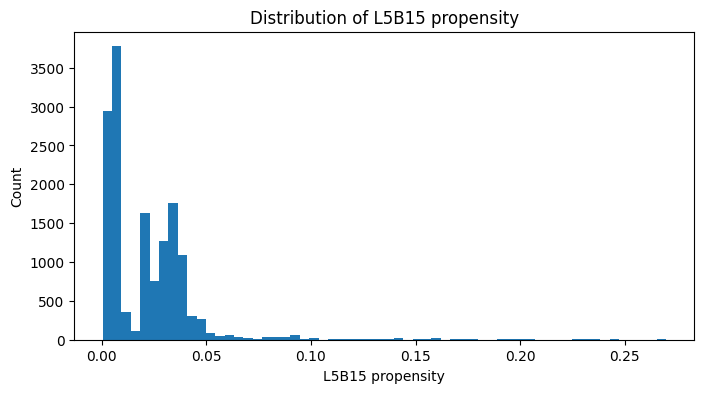

In [ ]:
### 6.3 Target Distribution


plt.figure(figsize=(8, 4))
plt.hist(df_model["propensity"], bins=60)
plt.xlabel("L5B15 propensity")
plt.ylabel("Count")
plt.title("Distribution of L5B15 propensity")
plt.show()

In [ ]:
### 6.4 Feature Correlation Analysis
df_num_try = df_model.copy()

for col in df_num_try.columns:
    if df_num_try[col].dtype == "object":
        df_num_try[col] = pd.to_numeric(df_num_try[col], errors="ignore")

num_cols = df_num_try.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c != "propensity"]

corr = df_num_try[num_cols + ["propensity"]].corr(numeric_only=True)["propensity"].drop("propensity")
corr.abs().sort_values(ascending=False).head(30)

modelPerformance    0.132815
modelEvidence       0.039740
Name: propensity, dtype: float64

In [ ]:
### 6.5 Categorical Feature Cardinality
cat_summary = pd.DataFrame({
    "n_unique": df_model.select_dtypes(include="object").nunique(dropna=True)
}).sort_values("n_unique", ascending=False)

cat_summary.head(30)

C:\Users\noah.bos\AppData\Local\Temp\ipykernel_29132\305572220.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  "n_unique": df_model.select_dtypes(include="object").nunique(dropna=True)


,n_unique
modelExecutionID,14834
pxInteractionID,8139
IH.Email.Outbound.Pending.pxLastOutcomeTime.DaysSince,6914
IH.Push.Outbound.Pending.pxLastOutcomeTime.DaysSince,6194
IH.Email.Inbound.Pending.pxLastOutcomeTime.DaysSince,5237
IH.Email.Inbound.Delivered.pxLastOutcomeTime.DaysSince,5138
IH.Email.Outbound.Delivered.pxLastOutcomeTime.DaysSince,4909
IH.Event.Outbound.RealTimeEvent.pxLastOutcomeTime.DaysSince,4607
IH.Mobile.Inbound.Impression.pxLastOutcomeTime.DaysSince,4247
CustBookedFlight.UpdateDateTime,3298


## 7. Surrogate Model Building

We build a CatBoost gradient-boosted surrogate to predict L5B15 propensity scores from the observable customer input features. The goal is not to outperform the Pega ADM model, but to approximate its scoring behavior closely enough to use the surrogate as an explainability proxy (e.g., with SHAP values).

In [ ]:
### 7.1 Feature Preparation
X = df_model.drop(columns=[c for c in [
    "propensity",
    "pxInteractionID",
    "pxSubjectID",
    "modelExecutionID",
    "pyName",
    "TreatmentID",
    "modelPerformance",
    "modelEvidence",
    "modelTechnique"
] if c in df_model.columns]).copy()

y = df_model["propensity"].astype(float).copy()

# drop very sparse and constant columns
X = X.loc[:, X.isna().mean() < 0.95]
X = X.loc[:, X.nunique(dropna=True) > 1]

# normalize obvious missing markers
X = X.replace({"": np.nan, "NaN": np.nan, "nan": np.nan, "None": np.nan})

# try numeric conversion safely
for col in X.columns:
    try:
        X[col] = pd.to_numeric(X[col])
    except Exception:
        pass

# identify categorical and numeric columns
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# clean categorical columns
for col in cat_cols:
    X[col] = X[col].astype("string").fillna("__MISSING__")

# clean numeric columns
for col in num_cols:
    X[col] = X[col].astype(float)
    X[col] = X[col].replace([np.inf, -np.inf], np.nan)
    X[col] = X[col].fillna(X[col].median())

print(X.shape)
print(len(num_cols), "numeric,", len(cat_cols), "categorical")

(14895, 225)
109 116


In [ ]:
### 7.2 Model Training
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from catboost import CatBoostRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cat_features = [X_train.columns.get_loc(c) for c in cat_cols]

model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="RMSE",
    eval_metric="RMSE",
    verbose=100,
    random_seed=42
)

model.fit(X_train, y_train, cat_features=cat_features)
pred = model.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

0:	learn: 0.0229860	total: 375ms	remaining: 3m 7s
100:	learn: 0.0116749	total: 19.7s	remaining: 1m 17s
200:	learn: 0.0108831	total: 42.7s	remaining: 1m 3s
300:	learn: 0.0103726	total: 1m 2s	remaining: 41.1s
400:	learn: 0.0099966	total: 1m 19s	remaining: 19.6s
499:	learn: 0.0096579	total: 1m 36s	remaining: 0us
R2: 0.6856065222618903
MAE: 0.006013836083536474


In [65]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

RMSE: 0.013986687731726396


### 7.3 Model Evaluation

The RMSE is relatively large compared to the mean propensity level. This is expected: propensity scores in Pega ADM span a wide range and the surrogate is approximating a black-box Bayesian classifier from observable inputs only. Absolute calibration is therefore less critical than whether the surrogate preserves rank order — which we assess next with the actual vs. predicted plot and Spearman correlation.

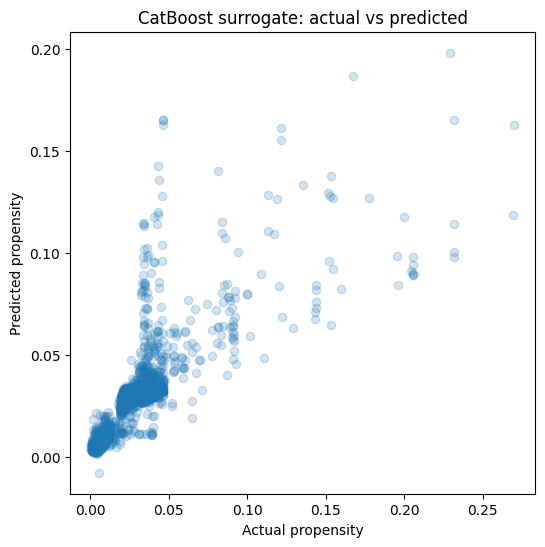

In [ ]:
### 7.4 Actual vs Predicted Plot
plt.scatter(y_test, pred, alpha=0.2)
plt.xlabel("Actual propensity")
plt.ylabel("Predicted propensity")
plt.title("CatBoost surrogate: actual vs predicted")
plt.show()

The scatter plot shows good rank fidelity overall: the surrogate correctly separates high-propensity from low-propensity cases. However, calibration is imperfect at the tails — extreme propensity values are compressed toward the center, predicting fewer very high or very low scores than the actual distribution contains. This is typical behavior for gradient-boosted surrogates and does not substantially impair their use as ranking tools.

In [ ]:
### 7.5 Rank Fidelity (Spearman Correlation)
rho, _ = spearmanr(y_test, pred)
print("Spearman rho:", rho)

Spearman rho: 0.8998057863448758


Spearman rank correlation measures agreement in ordering rather than absolute values. Since propensity scores are used operationally to rank offers, a surrogate that preserves rank order captures the most decision-relevant aspect of the original model’s behavior.

A Spearman ρ around 0.9 is a strong result: the surrogate reliably reproduces which customers are ranked higher or lower, even where it does not match the exact numeric propensity value. This makes it suitable as an explainability proxy.

In [ ]:
### 7.6 Feature Importance from Surrogate
fi = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.get_feature_importance()
}).sort_values("importance", ascending=False)

fi.head(30)

,feature,importance
0,pyChannel,30.932980
211,IH.Mobile.Inbound.Clicked.pxLastOutcomeTime.Da...,20.889631
191,param::Param.JourneyType,8.376424
210,IH.Mobile.Inbound.Clicked.pyHistoricalOutcomeC...,6.444160
212,IH.Mobile.Inbound.Clicked.pxLastGroupID,5.032540
187,param::Param.DaysInbetweenBookingAndFlight,3.118089
188,param::Param.Age,2.044716
68,IH.Mobile.Inbound.Impression.pxLastOutcomeTime...,1.701912
87,CustBookedFlight.CheckinStatus,1.615698
206,CustBookedFlight.BookingData.BookerCustomerID,1.238144


The table shows which variables CatBoost relied on most to reduce prediction error for propensity. A partition column like `pyChannel` ranking highly is suspicious: if all records in this dataset share the same channel (e.g., always "Email"), it carries no real predictive signal and its high importance reflects a data artifact. The next cell verifies whether these partition columns are effectively constant across the extracted records.

In [76]:
for c in ["pyChannel", "pyDirection", "pyGroup", "pyIssue", "pyName"]:
    if c in df_model.columns:
        print(c, df_model[c].value_counts(dropna=False).head())

pyChannel pyChannel
Mobile    7382
Email     3849
Web       3044
Push       620
Name: count, dtype: int64
pyDirection pyDirection
Inbound     11946
Outbound     2949
Name: count, dtype: int64
pyGroup pyGroup
Luggage              13375
FlightAncillaries     1520
Name: count, dtype: int64
pyIssue pyIssue
Sales    14895
Name: count, dtype: int64
pyName pyName
L5B15    14895
Name: count, dtype: int64


## 8. Model Version Analysis

L5B15 scoring events in the 3-day window are associated with multiple model versions. We inspect which versions were active and whether mean propensity differs across them — a sign of model drift that could contribute to the surrogate’s residual error.

In [77]:
model_counts = Counter()
combo_counts = Counter()

for record in df_l5b15.to_dicts():
    for me in record.get("pxModelExecutionResults", []) or []:
        raw_me = me.get("pxModelExecutionResults")
        if not raw_me:
            continue
        
        try:
            parsed_me = json.loads(raw_me)
        except Exception:
            continue
        
        partition = parsed_me.get("partition", {}) or {}
        pyname = partition.get("pyName")
        
        if pyname == "L5B15":
            model_version = parsed_me.get("modelVersion")
            combo = (
                model_version,
                partition.get("pyChannel"),
                partition.get("pyDirection"),
                partition.get("pyGroup"),
                partition.get("pyIssue"),
                partition.get("pyTreatment")
            )
            model_counts[model_version] += 1
            combo_counts[combo] += 1

print("Model versions:")
for k, v in model_counts.most_common():
    print(k, v)

print("\nCombinations:")
for k, v in combo_counts.most_common(20):
    print(v, k)

Model versions:
209d94cf-5f4d-5686-a597-4a77ec49c8d6 37
05c81636-dfe3-517a-beaf-d0779c97ec17 31
513a4eeb-7da7-5ae4-95c0-80cc4a65a12c 31
2aaa1723-af51-564b-8d86-acd593b0a3da 22
a29d35c3-a639-54fd-be82-31ac645b17bc 19
6e49516a-c2ac-5d66-b14e-6e6f4d5b34a6 17
8f1b9a74-c875-5f7e-8604-e24889e2905c 15
61ab5760-9a7b-5122-9749-846ae7202065 15
950e9bcc-d697-5011-a65d-e730206e53a1 14
7d80d3fa-d269-5dce-b083-5f981575028c 14
48107384-d0ef-503f-8479-6aac78fab76d 14
08e2708a-a325-58c6-9cd4-3d9f396744a6 14
8e68c9d8-ec48-5eb0-8b00-1bf070c076e5 13
2a073b26-2d39-5701-9040-2ff3e87251b9 13
4eaf4d56-141e-5874-b59a-a61b92e6e48c 13
ea0a64e8-9dbd-5a25-bcbf-6c2b2c6f2ae1 13
41eae18f-a26a-5d1c-badf-d5f2df005942 13
01c5a777-3679-58e3-aecf-44100be512aa 13
f444b71c-1127-58e8-8ead-8ed89e3e139a 13
261daa22-5a09-55c5-a401-2fe7e59b3a47 13
d103fc2d-ab01-5d1b-917b-7b414183f4ea 13
4213f02c-4669-595c-acc6-5fdf48ce0805 12
47d2a29d-cc83-5793-b1ae-92a083775232 12
82859a25-2a92-5987-b15e-e9cfed4819bd 12
ab31d5f9-5881-5bff-8aab-

In [84]:
def extract_filtered_model(df, pyname=None, pychannel=None, pydirection=None, pygroup=None, pyissue=None, model_version=None):
    rows = []

    for record in df.to_dicts():
        interaction_id = record.get("pxInteractionID")
        subject_id = record.get("pxSubjectID")
        common_inputs = parse_common_inputs(record)

        for me in record.get("pxModelExecutionResults", []) or []:
            raw_me = me.get("pxModelExecutionResults")
            if not raw_me:
                continue

            try:
                parsed_me = json.loads(raw_me)
            except Exception:
                continue

            partition = parsed_me.get("partition", {}) or {}
            values = parsed_me.get("values", {}) or {}
            param_preds = ((parsed_me.get("parameterPredictors") or {}).get("values") or {})

            if pyname is not None and partition.get("pyName") != pyname:
                continue
            if pychannel is not None and partition.get("pyChannel") != pychannel:
                continue
            if pydirection is not None and partition.get("pyDirection") != pydirection:
                continue
            if pygroup is not None and partition.get("pyGroup") != pygroup:
                continue
            if pyissue is not None and partition.get("pyIssue") != pyissue:
                continue
            if model_version is not None and parsed_me.get("modelVersion") != model_version:
                continue

            row = {
                "pxInteractionID": interaction_id,
                "pxSubjectID": subject_id,
                "modelVersion": parsed_me.get("modelVersion"),
                "modelExecutionID": parsed_me.get("modelExecutionID"),
                "pyName": partition.get("pyName"),
                "pyChannel": partition.get("pyChannel"),
                "pyDirection": partition.get("pyDirection"),
                "pyGroup": partition.get("pyGroup"),
                "pyIssue": partition.get("pyIssue"),
                "pyTreatment": partition.get("pyTreatment"),
                "TreatmentID": partition.get("TreatmentID"),
                "propensity": safe_float((values.get("pyPropensity") or {}).get("value")),
                "modelPerformance": safe_float((values.get("pyModelPerformance") or {}).get("value")),
                "modelEvidence": safe_float((values.get("pyModelEvidence") or {}).get("value")),
                "modelTechnique": (values.get("pyModelTechnique") or {}).get("value"),
                **common_inputs
            }

            for k, v in param_preds.items():
                row[f"param::{k}"] = v.get("value")

            rows.append(row)

    return pd.DataFrame(rows)

df_email = extract_filtered_model(
    df_l5b15,
    pyname="L5B15",
    pychannel="Email",
    pydirection="Outbound",
    pygroup="Luggage",
    pyissue="Sales"
)

print(df_email.shape)
print(df_email["modelVersion"].nunique())

(2329, 326)
1030


In [85]:
df_email["propensity"].describe()

count    2329.000000
mean        0.005834
std         0.006711
min         0.001468
25%         0.002648
50%         0.004245
75%         0.005950
max         0.074910
Name: propensity, dtype: float64

In [86]:
df_email.groupby("modelVersion")["propensity"].mean()

modelVersion
00345d66-10f8-5160-b8de-a14b3cf44410    0.002012
00682f04-53bb-54b2-8f8c-66670027f39a    0.001752
00dc9bce-6206-5c6b-8718-caafadeec0c3    0.011507
01b82ae6-03cc-5c25-b05e-b23bac1d88f1    0.004491
01c06724-a338-546f-8b06-a2be161bc293    0.001619
                                          ...   
ff4d1a9a-c575-58b8-bb4f-956a2c4e88ef    0.008526
ff832031-4f79-5a1b-b55b-13a79267f23e    0.002858
ffc0fa00-69ab-5750-a63a-91a80bb6a818    0.006245
ffda327d-97ae-5714-b173-a3bbb34bf74c    0.003747
ffef106e-66bd-53ea-ad80-b4013f3dba86    0.001660
Name: propensity, Length: 1030, dtype: float64

Mean propensity differs across model versions, confirming **model drift** within the 3-day observation window. When the underlying Pega ADM model updates between scoring events, identical customer inputs can yield different propensity values — introducing variance that a single surrogate cannot account for. This is the most likely driver of the elevated RMSE observed in Section 7.

**Implication**: For more precise surrogate modelling, records should be stratified by model version, or the analysis restricted to a single stable version. The filtered `df_email` extraction above provides a starting point for this.